# Модель прогнозирования оттока (Churn Prediction) для сервиса доставки кофе Happy Beans Coffee

Автор: Якунин Михаил

Дата: 10 мая 2026 г.

***По этой ссылке можно посмотреть исходный код проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint11_Customer_Churn_Forecast.git***

## Цель проекта

Разработать и внедрить модель бинарной классификации для прогнозирования оттока клиентов сервиса доставки кофе Happy Beans Coffee, позволяющую снизить уровень оттока с текущих 10% в месяц за счет точечного удержания клиентов и оптимизации маркетингового бюджета.

## Задача проекта

Для достижения поставленной цели необходимо решить следующие задачи:

1. Провести исследовательский анализ данных (EDA): Изучить структуру датасета, выявить закономерности, аномалии, пропуски и оценить степень несбалансированности классов (лояльные / уходящие клиенты).
2. Реализовать предобработку данных: Обработать пропущенные значения и привести категориальные признаки к формату, пригодному для обучения линейных моделей (кодирование).
3. Обучить базовую модель (Baseline): Создать точку отсчета для сравнения, используя DummyClassifier, и обучить линейную модель (LogisticRegression) для первичной оценки качества.
4. Повысить качество модели через инжиниринг признаков: Создать новые признаки, способные лучше отразить поведение клиента (возможно, комбинируя частоту, сумму и время), и отобрать наиболее информативные из них.
5. Оптимизировать гиперпараметры: Настроить параметры модели с использованием кросс-валидации для достижения максимального значения метрики PR AUC (как комбинированного показателя, фокусирующегося на классе оттока).
6. Оценить и зафиксировать результат: Оценить финальную модель на отложенной тестовой выборке, проверив её стабильность и эффективность с точки зрения баланса Precision и Recall (чтобы минимизировать ложные срабатывания).
7. Подготовить модель к промышленной эксплуатации: Сохранить обученный пайплайн предобработки и модель (через joblib) для дальнейшего использования в реальной системе прогнозирования.

## Содержание <a id=content></a>

1. [Подготовка среды и библиотек](#1)
2. [Первичный анализ данных](#2)
3. [Предобработка данных](#3)
4. [Обучение базовой версии модели](#4)
5. [Создание новых признаков](#5)
6. [Эксперименты с гиперпараметрами](#6)
7. [Подготовка финальной модели](#7)
8. [Отчёт о проделанной работе](#8)
9. [Сохранение модели для продакшена](#9)


## [Этап 1. Подготовка среды и библиотек <a id=1></a>](#content)

In [1]:
# Загружаем все необходимые библиотеки
#!pip install requirements.txt

In [2]:
# Загружаем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, average_precision_score


In [3]:
# Загружаем датасет
df = pd.read_csv('datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

In [4]:
# Фиксируем константные значения
random_state = 11

## [Этап 2. Первичный анализ данных <a id=2></a>](#content)

In [5]:
# Выводим общую информацию о датафрейме
display(df.head(5))
df.info()
df.describe(include='all').T

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10450,10450,user_00318,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_last_order,9505.0,NaN,NaN,NaN,4.394214,4.858757,0.0,1.0,3.0,6.0,40.0
order_frequency_month,9850.0,NaN,NaN,NaN,4.025666,2.826144,0.011046,1.937767,3.381094,5.439363,27.389318
order_frequency_week,10062.0,NaN,NaN,NaN,0.930686,0.657261,-0.169131,0.445185,0.784839,1.26235,6.302624
avg_order_value,9867.0,NaN,NaN,NaN,1063.741207,707.713396,-32.075932,552.898663,898.643524,1406.332153,5901.965278
median_order_value,9619.0,NaN,NaN,NaN,452.6515,258.657571,-10.35334,262.908598,406.456818,590.41807,2189.101644
total_spent_last_month,10156.0,NaN,NaN,NaN,1946.132979,2370.61959,-43.716463,629.680382,1300.409757,2481.650495,79298.84957
total_spent_last_week,9506.0,NaN,NaN,NaN,413.00476,445.634902,-2290.559468,136.565833,288.277327,549.69942,8615.988952
discount_usage_rate,10053.0,NaN,NaN,NaN,0.284446,0.158735,0.002162,0.159884,0.264583,0.387056,0.887301
last_coffee_type,10192,3,arabica,6134,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**1. Краткое описание данных:**

Датасет `coffee_churn_dataset` содержит информацию о 10 450 уникальных клиентах сервиса доставки кофе Happy Beans Coffee. Данные агрегированы за последние 4 недели и представляют собой аналитическую витрину, где каждая строка соответствует одному клиенту.

Что известно о пользователях и их поведении:
- Активность и транзакции: частота заказов (в месяц и неделю), время с последнего заказа, сумма трат (за месяц и неделю), средний и медианный чек.
- Предпочтения: тип кофе (arabica, robusta, blend), степень обжарки, тип молока, размер напитка, страна происхождения зерна.
- Взаимодействие с сервисом: частота открытия приложения, включены ли уведомления, сколько раз приложение зависало, пробовал ли пользователь сезонное меню.
- Маркетинговое взаимодействие: доля заказов со скидкой, время с последнего использования промокода, статус подписки.
- Обратная связь: средняя оценка за последние 10 заказов и оценка за последний заказ.
- Технические и географические данные: тип устройства (android/ios/web), регион (geo_id), менялись ли вкусовые предпочтения.
- Целевая переменная: churn — ушёл клиент (1) или остался лоялен (0).

**2. Целевая переменная:**

<u>Анализ распределения:</u>
- `churn` имеет mean = 0.060191 (около 6.02%)
- std = 0.237852
- min = 0, max = 1
- 25%, 50%, 75% = 0 (все квартили — 0)

<u>Проверка дисбаланса классов:</u>

Вычислим точное соотношение:
- Количество лояльных клиентов (churn = 0): 10450 × (1 - 0.060191) ≈ 9818 клиентов
- Количество уходящих клиентов (churn = 1): 10450 × 0.060191 ≈ 632 клиента

Наблюдается сильный дисбаланс классов — примерно 94% лояльных и 6% уходящих клиентов. Это типичная ситуация для задач прогнозирования оттока и подтверждает необходимость использования метрики PR AUC (а не accuracy), как указано в требованиях заказчика.

**3. Признаки которые можно удалить**

| Признак | Причина для удаления |
| :--- | :--- |
| `user_id` | Уникальный идентификатор не несёт информации, модель не может обобщать по нему. Может привести к переобучению. |
| `order_frequency_week` и `order_frequency_month` | Эти признаки сильно коррелируют между собой (логично: частота за неделю × 4 ≈ частота за месяц). Один из них можно удалить для снижения мультиколлинеарности. |
| `total_spent_last_month` и `total_spent_last_week` | Аналогично — недельные траты являются частью месячных. Сильная корреляция. |
| `review_rating_last_10` и `review_rating_last_1` | Один из этих признаков может быть менее информативным. Оценка за 1 заказ может быть случайной, средняя за 10 заказов более стабильна. |

**4. Пропущенные значения**

Из информации о датасете видно, что пропуски есть почти во всех признаках:
- Наименьшее количество пропусков: preferred_roast (10334/10450, ~1% пропусков)
- Наибольшее количество пропусков: seasonal_menu_tried (9461/10450, ~9.5% пропусков)

Пропуски могут возникать из-за:
- Отсутствия активности клиента (например, days_since_last_order = NaN может означать, что клиент никогда не делал заказ)
- Технических проблем сбора данных
-Отсутствия информации в опросах

<u>Стратегия заполнения пропусков</u>

| Тип признака | Стратегия | Обоснование |
| :--- | :--- | :--- |
| Числовые (количество дней, частота, сумма) | Медиана | Распределение скорее всего асимметричное (судя по разнице mean и median), медиана устойчива к выбросам |
| Числовые (бинарные: `seasonal_menu_tried`, `notifications_enabled` и др.) | Мода (наиболее частое значение) | Для бинарных/категориальных признаков логично использовать наиболее вероятное значение |
| Категориальные (`last_coffee_type`, `preferred_roast` и др.) | Мода (наиболее частое значение) | Заполнение самой популярной категорией — стандартный подход |
| `days_since_last_order = NaN` | Максимальное значение + 1 (или большое число, например 60) | Если заказа не было, это само по себе информативно — такой клиент скорее склонен к оттоку |

**5. Категориальные признаки**

В датафрейме имеются 9 категориальных признаков. Линейниые модели машинного обучения (включая LogisticRegression) работают только с числовыми данными. Категориальные признаки необходимо преобразовать в числовой формат.

<u>Стратегия кодирования:</u>
- Для geo_location (100 категорий) — Target Encoding (кодирование средним значением целевой переменной по группе), так как One-Hot создаст слишком много признаков.
- Для остальных признаков (3 - 6 признаков) - One-Hot Encoding или порядковое кодирование (если есть явный порядок).

**6. Генерации новых признаков**

Генерация новых признаков позволяет выявить скрытые закономерности в поведении клиентов, которые напрямую не отражены в исходных данных. Хорошо спроектированные признаки часто оказываются более информативными для модели, чем исходные, и могут значительно повысить качество прогнозирования оттока.
| Исходные признаки | Новый признак | Обоснование |
| :--- | :--- | :--- |
| `total_spent_last_month` / `order_frequency_month` | `avg_spend_per_order` | Средний чек можно вычислить и сравнить с avg_order_value для проверки согласованности |
| `days_since_last_promo` * `discount_usage_rate` | `promo_engagement` | Клиенты, которые активно используют промокоды, могут быть более чувствительны к скидкам |
| `days_since_last_order` / `order_frequency_week` | `risk_score` | Давно не заказывал / раньше заказывал часто = высокий риск оттока |

**7. Анализ выбросов**

Из описательной статистики видны аномалии:
| Признак | Проблема |
| :--- | :--- |
| `order_frequency_week`<br>`avg_order_value`<br>`median_order_value`<br>`total_spent_last_month`<br>`total_spent_last_week`<br>`review_rating_last_1`| Минимальное значение отрицательное |
| `avg_order_value`<br>`median_order_value`<br>`total_spent_last_month`<br>`total_spent_last_week` | Максимальное значение в дисятки превышает среднее значение|

<u>Влияние выбросов:</u>
- Искажают средние значения (mean сильно отличается от median)
- Могут привести к переобучению модели
- Линейные модели (логистическая регрессия) чувствительны к выбросам

<u>Способы обработки выбросов:</u>
- Для отрицательных значений (ошибки данных):
    * Заменить на медиану признака
    * Значения ниже Q3 - 3×IQR считать выбросами и заменить на Q3 - 3×IQR
    * Или заменить на 1-й перцентиль
- Для аномально высоких значений (траты, частота открытий):
    * Использовать метод IQR (межквартильный размах)
    * Значения выше Q3 + 3×IQR считать выбросами и заменить на Q3 + 3×IQR
    * Или заменить на 99-й перцентиль

**8. Корреляции между признаками**

Составим корреляционную матрицу для выявления взаимосвязных признаков: 

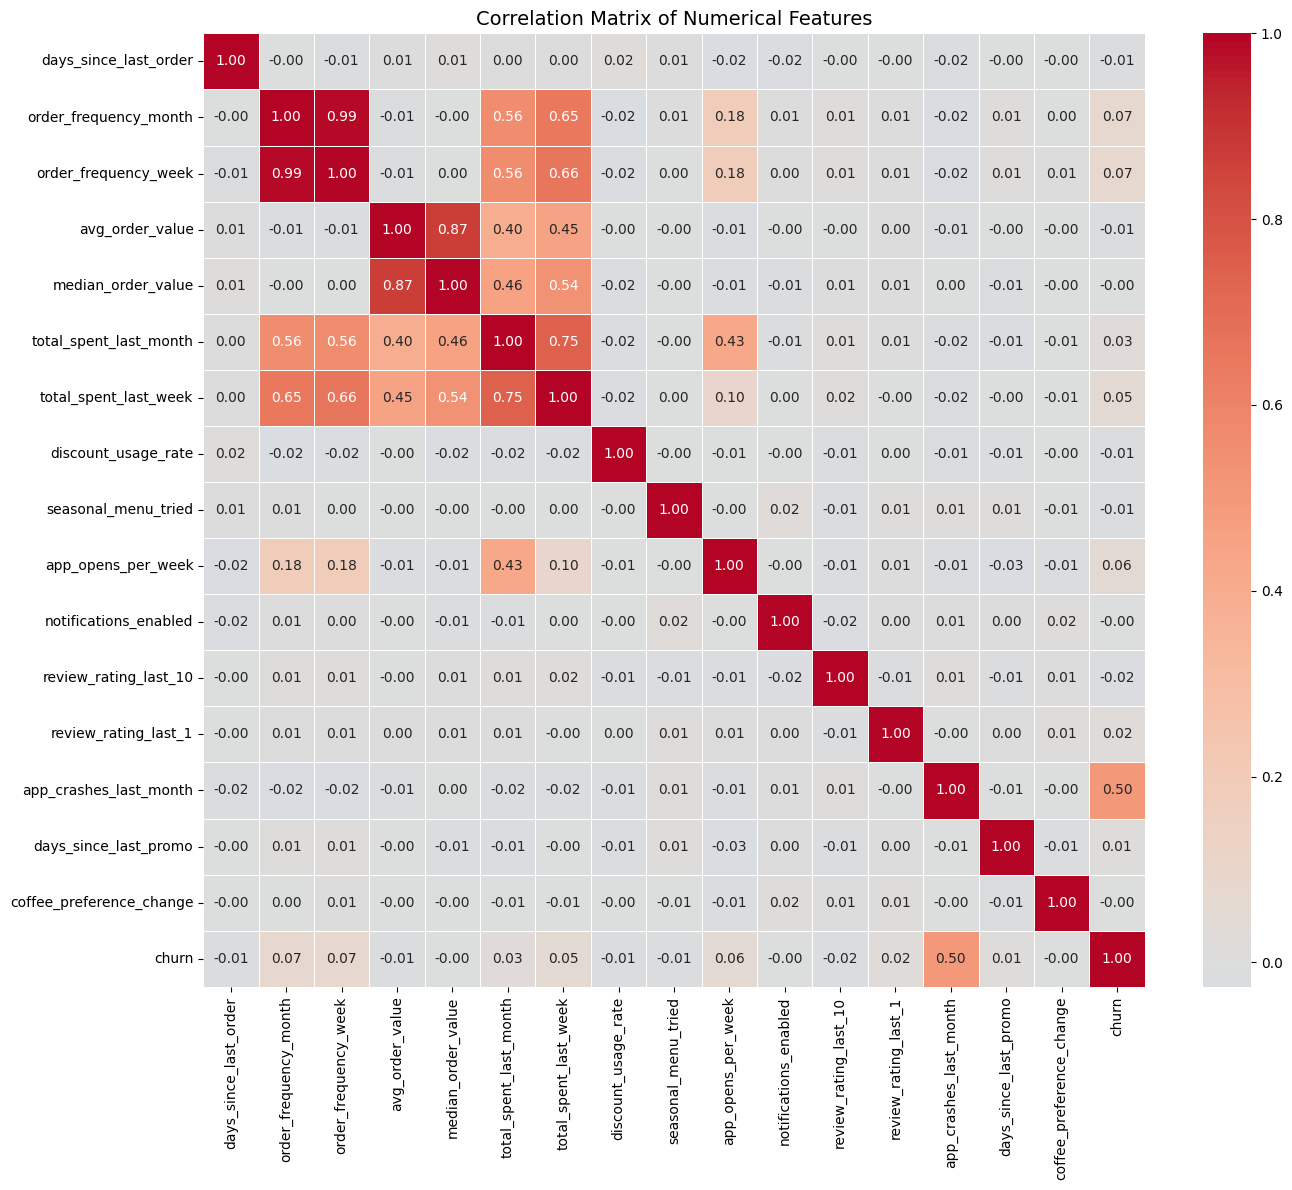

In [6]:
# Тепловая карта корреляций признаков
plt.figure(figsize=(14, 12))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), 
            annot=True,     
            fmt='.2f',      
            cmap='coolwarm', 
            center=0,
            linewidths=0.5, 
            linecolor='white')
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()  
plt.show()

Как видно из тепловой карты, что признаки указаные ранее на удаление имеют высокую корреляцию. Но так же имеется корреляция между avg_order_value и median_order_value. Для дальнейшего построения модели можно оставить только один признак. 

**9. Дальнейшие шаги:**
- Удалить все не нужные признаки.
- Обработать выбросы и отрицательные значения.
- Заполнить пропуски с учётом типа признака
- Закодировать категориальные переменные
- Сгенерировать новые признаки.

## [Этап 3. Предобработка данных <a id=3></a>](#content)

### 3.1 Удаление не информативных признаков

До выполнения предобработки и разделения данных необходимо удали не информативные признаки или сильно коррелируемые между собой. Признаки для удаления были определены в первичном анализе данных.
| Признак | Причина для удаления |
| :--- | :--- |
| `user_id` | Уникальный идентификатор, не несёт предсказательной силы |
| `order_frequency_week` | Показатель за месяц более стабильный показатель, чем недельный |
| `total_spent_last_week` | Показатель за месяц дает полную картину трат, чем недельный показатель |
| `review_rating_last_1` | Оценка за 1 заказ может быть случайной, средняя за 10 заказов более стабильна. |
| `avg_order_value` | Сильно коррелируется с признаком `median_order_value`. Медиана устойчива к выбросам, а выбросы в avg_order_value есть|

In [7]:
# Удаляем не нужные признаки
columns_to_drop = [
    'user_id', 
    'order_frequency_week', 
    'total_spent_last_week', 
    'review_rating_last_1', 
    'avg_order_value'
]
df_clean = df.drop(columns=columns_to_drop)

print(f"\nИсходное количество признаков: {df.shape[1]}")
print(f"Количество признаков после удаления: {df_clean.shape[1]}")
print(f"Удалено признаков: {df.shape[1] - df_clean.shape[1]}")


Исходное количество признаков: 27
Количество признаков после удаления: 22
Удалено признаков: 5


### 3.2 Предобработка выбросов в данных

После удаления не информативных признаков, в датафрейме осталось только 2 признака с выбросами `median_order_value` и `total_spent_last_month`, в виде отрицательных значений. Так как такие признаки будут приводить к ошибкам в предобработке данных (масштабирование, кодирование и т.д.), то их стоит обработать до разделение данных на выборки.

In [8]:
# Выводим общую информацию о датафрейме
df_clean.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
days_since_last_order,9505.0,NaN,NaN,NaN,4.394214,4.858757,0.0,1.0,3.0,6.0,40.0
order_frequency_month,9850.0,NaN,NaN,NaN,4.025666,2.826144,0.011046,1.937767,3.381094,5.439363,27.389318
median_order_value,9619.0,NaN,NaN,NaN,452.6515,258.657571,-10.35334,262.908598,406.456818,590.41807,2189.101644
total_spent_last_month,10156.0,NaN,NaN,NaN,1946.132979,2370.61959,-43.716463,629.680382,1300.409757,2481.650495,79298.84957
discount_usage_rate,10053.0,NaN,NaN,NaN,0.284446,0.158735,0.002162,0.159884,0.264583,0.387056,0.887301
last_coffee_type,10192,3,arabica,6134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_roast,10334,3,medium,3458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
milk_preference,9782,6,whole,2876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seasonal_menu_tried,9461.0,NaN,NaN,NaN,0.701194,0.457759,0.0,0.0,1.0,1.0,1.0
coffee_bean_origin,9768,6,ethiopia,1690,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Выводим строки с отрицательными значениями
df_clean[(df_clean['median_order_value'] < 0) | (df_clean['total_spent_last_month'] < 0)]

,days_since_last_order,order_frequency_month,median_order_value,total_spent_last_month,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,...,app_opens_per_week,notifications_enabled,review_rating_last_10,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
8176,0.0,3.839381,-10.353340,-43.716463,0.500261,arabica,light,whole,1.0,colombia,...,13.652514,1.0,5.113545,0.0,winter,20.0,NaN,0.0,geo_1,0
9233,6.0,2.220828,-7.325263,-14.737615,0.101484,robusta,dark,whole,1.0,colombia,...,6.756336,1.0,3.720842,1.0,winter,1.0,web,0.0,geo_96,0


как видно таких строк только 2, поэтому их можно удалить.

In [10]:
# Отфильтруем строки с отрицательными значениями
df_clean = df_clean[~((df_clean['median_order_value'] < 0) | (df_clean['total_spent_last_month'] < 0))]

In [53]:
# Выводим общую информацию о датафрейме
df_clean.describe(include='all').round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
days_since_last_order,9503.0,NaN,NaN,NaN,4.39,4.86,0.0,1.0,3.0,6.0,40.0
order_frequency_month,9848.0,NaN,NaN,NaN,4.03,2.83,0.01,1.94,3.38,5.44,27.39
median_order_value,9617.0,NaN,NaN,NaN,452.75,258.6,2.09,263.02,406.48,590.5,2189.1
total_spent_last_month,10154.0,NaN,NaN,NaN,1946.52,2370.69,5.01,630.46,1300.42,2482.11,79298.85
discount_usage_rate,10051.0,NaN,NaN,NaN,0.28,0.16,0.0,0.16,0.26,0.39,0.89
last_coffee_type,10190,3,arabica,6133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_roast,10332,3,medium,3458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
milk_preference,9780,6,whole,2874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seasonal_menu_tried,9459.0,NaN,NaN,NaN,0.7,0.46,0.0,0.0,1.0,1.0,1.0
coffee_bean_origin,9766,6,ethiopia,1690,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.3 Разделение данных на выборки

In [12]:
# Определяем признаки (Х) и целевую переменную (у)
X = df_clean.drop(columns='churn')
y = df_clean['churn']

# Разделяем данные: 80% - обучающая выборка, 20% - тестовая выборка
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")
print(f"Доля оттока в обучающей: {y_train.mean():.4f}")
print(f"Доля оттока в тестовой: {y_test.mean():.4f}")

Размер обучающей выборки: 8358 строк
Размер тестовой выборки: 2090 строк
Доля оттока в обучающей: 0.0602
Доля оттока в тестовой: 0.0603


Использование `stratify=y` гарантирует, что пропорция уходящих и лояльных клиентов (`≈6%`) сохранится и в обучающей, и в тестовой выборках.

### 3.4 Предобработка данных

In [13]:
# Определяем типы признаков
categorical_cols = X_train.select_dtypes(include=['str']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [14]:
# Пайплайн для категориальных признаков
categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]
)

In [15]:
# Пайплайн для числовых признаков
numerical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [16]:
# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='drop'
)

In [17]:
# Применяем общий препроцес для выборок
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Обработано: train {X_train_processed.shape}, test {X_test_processed.shape}")

Обработано: train (8358, 135), test (2090, 135)


## [Этап 4. Обучение базовой версии модели <a id=4></a>](#content)

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [18]:
# Определим список метрик
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',           
    'recall': 'recall',                 
    'average_precision': 'average_precision'  
}

In [19]:
# Определим функции для вывода основных метрик
def print_cross_validation_metrics(model, name_model):
    print("\n" + "=" * 60)
    print(f"СРЕДНИЕ ЗНАЧЕНИЯ ПО ВСЕМ ФОЛДАМ для модели {name_model}:")
    print("=" * 60)
    print(f"Средняя Accuracy:  {np.mean(model['test_accuracy']):.4f} (+/- {np.std(model['test_accuracy']):.4f})")
    print(f"Средняя Precision: {np.mean(model['test_precision']):.4f} (+/- {np.std(model['test_precision']):.4f})")
    print(f"Средняя Recall:    {np.mean(model['test_recall']):.4f} (+/- {np.std(model['test_recall']):.4f})")
    print(f"Средняя PR AUC:    {np.mean(model['test_average_precision']):.4f} (+/- {np.std(model['test_average_precision']):.4f})")

In [20]:
# Создаем объект кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

In [21]:
def creat_cross_validate(model, X_train, y_train, scoring, skf):
    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        return_estimator=False,
        return_train_score=False,
        n_jobs=-1
    )
    return result

**DummyClassifier (базовая линия - Baseline)**

DummyClassifier предсказывает наиболее частый класс (в нашем случае "лояльный", так как отток ~6%). Эта модель служит нижней границей качества — любая полезная модель должна быть лучше.

In [22]:
# Обучаем DummyClassifier
model_dummy_clf = DummyClassifier(strategy='most_frequent', random_state=random_state)


In [23]:
# Получаем предсказания для DummyClassifier через cross_validate
cv_dummy_results = creat_cross_validate(
    model_dummy_clf, 
    X_train_processed, 
    y_train, 
    scoring, 
    skf
)

In [24]:
# Выаодим метрику по модели
print_cross_validation_metrics(cv_dummy_results, 'DummyClassifier')


СРЕДНИЕ ЗНАЧЕНИЯ ПО ВСЕМ ФОЛДАМ для модели DummyClassifier:
Средняя Accuracy:  0.9398 (+/- 0.0003)
Средняя Precision: 0.0000 (+/- 0.0000)
Средняя Recall:    0.0000 (+/- 0.0000)
Средняя PR AUC:    0.0602 (+/- 0.0003)


In [26]:
# Обучаем LogisticRegression
model_lr_balans = LogisticRegression(class_weight='balanced', random_state=random_state)

In [27]:
# Получаем предсказания для LogisticRegression через cross_validate
cv_lr_balance_results = creat_cross_validate(
    model_lr_balans, 
    X_train_processed, 
    y_train, 
    scoring, 
    skf
)

In [28]:
print_cross_validation_metrics(cv_lr_balance_results, 'LogisticRegression')


СРЕДНИЕ ЗНАЧЕНИЯ ПО ВСЕМ ФОЛДАМ для модели LogisticRegression:
Средняя Accuracy:  0.8685 (+/- 0.0022)
Средняя Precision: 0.2917 (+/- 0.0088)
Средняя Recall:    0.8309 (+/- 0.0410)
Средняя PR AUC:    0.5794 (+/- 0.0397)


### Промежуточный вывод

1. DummyClassifier (baseline)
    - `Accuracy` ≈ 94% → высокая за счёт дисбаланса классов
    - `Precision` = 0, Recall = 0, PR AUC ≈ 0.06 → модель полностью несостоятельна для предсказания целевого класса

`DummyClassifier` показывает, что простая стратегия предсказания преобладающего класса даёт иллюзию высокой точности, но реальной предсказательной силы по целевому классу — ноль.

2. LogisticRegression (`class_weight='balanced'`)
    - `Accuracy`:   86.85% — немного ниже, чем у Dummy, но это честная цена за обучение на обоих классах
    - `Precision`:  0.2917 — из всех предсказанных положительных классов только ~29% верны (много ложных срабатываний)
    - `Recall`:     0.8309 — модель находит ~83% всех реальных положительных объектов (хорошая чувствительность)
    - `PR AUC`:     0.5794 — значительно выше Dummy, но пока не отличный

Логистическая регрессия с балансировкой классов уверенно превосходит базовую линию по всем метрикам, имеющим смысл для целевого класса (`Recall`, `Precision`, `PR AUC`). В качестве основного `baseline` для сравнения новых моделей следует использовать `LogisticRegression` (а не `DummyClassifier`), так как она уже показывает осмысленную предсказательную способность по целевому классу.

## [Этап 5. Создание новых признаков <a id=5></a>](#content)

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

1. Квадратный корень — `√x`

| Признак | Исходный разброс (min–max) | Формула | Цель |
|:---|:---|:---|:---|
| `sqrt_total_spent_last_month` | 5 — 79 299 | `√(total_spent_last_month)` | Сумма трат имеет экстремальные выбросы |
| `sqrt_median_order_value` | 2 — 2 189 | `√(median_order_value)` | Медианный чек также подвержен выбросам |
| `sqrt_app_opens_per_week` | 0 — 225 | `√(app_opens_per_week)` | Частота открытий варьируется на порядки |
| `sqrt_days_since_last_promo` | 0 — 140 | `√(days_since_last_prom)` | Сглаживает влияние давних акций |

2. Отношение — `x / y`

| Признак | Формула | Обоснование |
|:---|:---|:---|
| `avg_spend_per_order` | `total_spent_last_month` / `order_frequency_month` | Средний чек за заказ (базовая LTV-метрика) |
| `risk_score` | `days_since_last_order` / `order_frequency_week` | Давно не заказывал, но раньше заказывал часто → высокий риск |

3. Произведение — `x × y`

| Признак | Формула | Обоснование |
|:---|:---|:---|
| `promo_engagement` | `days_since_last_promo` * `discount_usage_rate` | Прямая зависимость от давности и от использования скидок |

In [55]:
# Функция для добавления новых признаков на основе исходных
def add_features(df):
    
    df_new = df.copy()
    
    # Квадратный корень для сглаживания больших значений
    df_new['sqrt_total_spent_last_month'] = np.sqrt(df_new['total_spent_last_month'])
    df_new['sqrt_median_order_value'] = np.sqrt(df_new['median_order_value'])
    df_new['sqrt_app_opens_per_week'] = np.sqrt(df_new['app_opens_per_week'])
    df_new['sqrt_days_since_last_promo'] = np.sqrt(df_new['days_since_last_promo'])
    
    # Отнашение признаков
    df_new['avg_spend_per_order'] = df_new['total_spent_last_month'] / (df_new['order_frequency_month'] + + 0.01)
    df_new['risk_score'] = df_new['days_since_last_order'] / (df_new['order_frequency_month'] + 0.01)
    
    return df_new

In [56]:
# Применяем добавление признаков к исходным данным
df_clean_with_features = add_features(df_clean)

print(f"Исходное количество признаков: {df_clean.shape[1]}")
print(f"Количество признаков после добавления: {df_clean_with_features.shape[1]}")
print(f"Добавлено признаков: {df_clean_with_features.shape[1] - df_clean.shape[1]}")
display(df_clean_with_features.describe(include='all').round(2).T)

Исходное количество признаков: 22
Количество признаков после добавления: 28
Добавлено признаков: 6


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
days_since_last_order,9503.0,NaN,NaN,NaN,4.39,4.86,0.0,1.0,3.0,6.0,40.0
order_frequency_month,9848.0,NaN,NaN,NaN,4.03,2.83,0.01,1.94,3.38,5.44,27.39
median_order_value,9617.0,NaN,NaN,NaN,452.75,258.6,2.09,263.02,406.48,590.5,2189.1
total_spent_last_month,10154.0,NaN,NaN,NaN,1946.52,2370.69,5.01,630.46,1300.42,2482.11,79298.85
discount_usage_rate,10051.0,NaN,NaN,NaN,0.28,0.16,0.0,0.16,0.26,0.39,0.89
last_coffee_type,10190,3,arabica,6133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_roast,10332,3,medium,3458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
milk_preference,9780,6,whole,2874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seasonal_menu_tried,9459.0,NaN,NaN,NaN,0.7,0.46,0.0,0.0,1.0,1.0,1.0
coffee_bean_origin,9766,6,ethiopia,1690,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Разделяем данные с новыми признаками
X_features = df_clean_with_features.drop(columns='churn')
y_features = df_clean_with_features['churn']

In [43]:
# Разделяем данные: 80% - обучающая выборка, 20% - тестовая выборка
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X_features, y_features,
    test_size=0.2,
    random_state=random_state,
    stratify=y_features
)

In [58]:
# Определяем типы признаков
categorical_cols_feat = X_train_feat.select_dtypes(include=['str']).columns.tolist()
numerical_cols_feat = X_train_feat.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [60]:
# # Создаем обновленный препроцессор
preprocessor_feat = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols_feat),
        ('cat', categorical_pipeline, categorical_cols_feat)
    ],
    remainder='drop'
)

In [62]:
# Применяем обновленый препроцессинг
X_train_feat_processed = preprocessor_feat.fit_transform(X_train_feat)
X_test_feat_processed = preprocessor_feat.transform(X_test_feat)

print(f"\nОбработано с новыми признаками: train {X_train_feat_processed.shape}, test {X_test_feat_processed.shape}")


Обработано с новыми признаками: train (8358, 141), test (2090, 141)


In [64]:
# Обучаем модель с новыми признаками
cv_lr_feat_results = creat_cross_validate(
    model_lr_balans, 
    X_train_feat_processed, 
    y_train_feat, 
    scoring, 
    skf
)

In [65]:
# Выводим результаты модели с новыми признаками
print_cross_validation_metrics(cv_lr_feat_results, "LogisticRegression (с новыми признаками)")


СРЕДНИЕ ЗНАЧЕНИЯ ПО ВСЕМ ФОЛДАМ для модели LogisticRegression (с новыми признаками):
Средняя Accuracy:  0.8751 (+/- 0.0028)
Средняя Precision: 0.3037 (+/- 0.0097)
Средняя Recall:    0.8329 (+/- 0.0391)
Средняя PR AUC:    0.6151 (+/- 0.0348)


In [ ]:
# Функция для сравнения результатов
def compare_models(baseline_results, new_results):
    print("\n" + "=" * 70)
    print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ: БАЗОВАЯ МОДЕЛЬ vs МОДЕЛЬ С НОВЫМИ ПРИЗНАКАМИ")
    print("=" * 70)
    
    metrics = ['accuracy', 'precision', 'recall', 'average_precision']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'PR AUC']
    
    for metric, name in zip(metrics, metric_names):
        baseline_mean = np.mean(baseline_results[f'test_{metric}'])
        new_mean = np.mean(new_results[f'test_{metric}'])
        improvement = (new_mean - baseline_mean) * 100
        
        print(f"\n{name}:")
        print(f"  Базовая модель:     {baseline_mean:.4f}")
        print(f"  Модель с признаками: {new_mean:.4f}")
        print(f"  Улучшение:          {improvement:+.2f}%")

# Сравниваем с базовой моделью
compare_models(cv_lr_balance_results, cv_lr_feat_results)


СРАВНЕНИЕ РЕЗУЛЬТАТОВ: БАЗОВАЯ МОДЕЛЬ vs МОДЕЛЬ С НОВЫМИ ПРИЗНАКАМИ

Accuracy:
  Базовая модель:     0.8751
  Модель с признаками: 0.8751
  Улучшение:          +0.00%

Precision:
  Базовая модель:     0.3037
  Модель с признаками: 0.3037
  Улучшение:          +0.00%

Recall:
  Базовая модель:     0.8329
  Модель с признаками: 0.8329
  Улучшение:          +0.00%

PR AUC:
  Базовая модель:     0.6151
  Модель с признаками: 0.6151
  Улучшение:          +0.00%


In [67]:
# Обучаем модель на всех тренировочных данных для получения коэффициентов
model_for_coef = LogisticRegression(class_weight='balanced', random_state=random_state, max_iter=1000)
model_for_coef.fit(X_train_feat_processed, y_train_feat)

# Получаем названия признаков после one-hot кодирования
feature_names = (
    numerical_cols_feat + 
    list(preprocessor_feat.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols_feat))
)

# Создаем DataFrame с коэффициентами
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model_for_coef.coef_[0]
})

# Добавляем абсолютное значение для сортировки
coef_df['abs_coefficient'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print("=" * 70)
print("ТОП-20 НАИБОЛЕЕ ЗНАЧИМЫХ ПРИЗНАКОВ (по модулю коэффициента)")
print("=" * 70)
print(coef_df.head(20).to_string(index=False))

# Анализ влияния признаков (положительные и отрицательные)
print("\n" + "=" * 70)
print("ПРИЗНАКИ, УВЕЛИЧИВАЮЩИЕ РИСК ОТТОКА (положительные коэффициенты)")
print("=" * 70)
increasing_risk = coef_df[coef_df['coefficient'] > 0].head(10)
print(increasing_risk.to_string(index=False))

print("\n" + "=" * 70)
print("ПРИЗНАКИ, СНИЖАЮЩИЕ РИСК ОТТОКА (отрицательные коэффициенты)")
print("=" * 70)
decreasing_risk = coef_df[coef_df['coefficient'] < 0].head(10)
print(decreasing_risk.to_string(index=False))

ТОП-20 НАИБОЛЕЕ ЗНАЧИМЫХ ПРИЗНАКОВ (по модулю коэффициента)
                feature  coefficient  abs_coefficient
sqrt_app_opens_per_week     2.261704         2.261704
    geo_location_geo_11     2.250685         2.250685
    geo_location_geo_86     2.187216         2.187216
    geo_location_geo_74     2.109856         2.109856
 app_crashes_last_month     2.104731         2.104731
    geo_location_geo_85     2.065448         2.065448
    geo_location_geo_56     2.043955         2.043955
    geo_location_geo_31     2.013887         2.013887
    geo_location_geo_33     1.834458         1.834458
    geo_location_geo_44     1.721208         1.721208
    geo_location_geo_89    -1.622193         1.622193
    geo_location_geo_41    -1.612800         1.612800
    geo_location_geo_30     1.590948         1.590948
     geo_location_geo_8    -1.547946         1.547946
    geo_location_geo_36    -1.513317         1.513317
     app_opens_per_week    -1.466759         1.466759
    geo_location_geo_4

In [68]:
# Анализ важности признаков с помощью RFE (Recursive Feature Elimination)
from sklearn.feature_selection import RFECV

# Используем RFECV для автоматического отбора признаков
print("\n" + "=" * 70)
print("ОТБОР ПРИЗНАКОВ С ПОМОЩЬЮ RFECV")
print("=" * 70)

selector = RFECV(
    LogisticRegression(class_weight='balanced', random_state=random_state, max_iter=1000),
    cv=skf,
    scoring='average_precision',
    min_features_to_select=20,
    n_jobs=-1
)

selector.fit(X_train_feat_processed, y_train_feat)

print(f"Оптимальное количество признаков: {selector.n_features_}")
print(f"Количество признаков до отбора: {X_train_feat_processed.shape[1]}")
print(f"Количество признаков после отбора: {selector.n_features_}")
print(f"Сокращение: {(1 - selector.n_features_/X_train_feat_processed.shape[1])*100:.1f}%")

# Получаем маску выбранных признаков
selected_features_mask = selector.support_
selected_feature_names = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask[i]]

print(f"\nВыбрано признаков: {len(selected_feature_names)}")
print("Топ-10 отобранных признаков:")
for i, feat in enumerate(selected_feature_names[:10]):
    coef_val = coef_df[coef_df['feature'] == feat]['coefficient'].values[0] if feat in coef_df['feature'].values else 0
    print(f"  {i+1}. {feat} (коэф: {coef_val:.4f})")

# Создаем уменьшенную версию данных
X_train_reduced = X_train_feat_processed[:, selected_features_mask]
X_test_reduced = X_test_feat_processed[:, selected_features_mask]

print(f"\nРазмерность после отбора признаков:")
print(f"  Train: {X_train_reduced.shape}")
print(f"  Test: {X_test_reduced.shape}")

# Обучаем модель на отобранных признаках
model_lr_reduced = LogisticRegression(class_weight='balanced', random_state=random_state, max_iter=1000)

cv_lr_reduced_results = creat_cross_validate(
    model_lr_reduced,
    X_train_reduced,
    y_train_feat,
    scoring,
    skf
)

print("\n" + "=" * 70)
print("РЕЗУЛЬТАТЫ МОДЕЛИ ПОСЛЕ ОТБОРА ПРИЗНАКОВ")
print("=" * 70)
print_cross_validation_metrics(cv_lr_reduced_results, "LogisticRegression (после отбора признаков)")

# Финальное сравнение всех трех моделей
print("\n" + "=" * 70)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 70)

models_comparison = {
    'Baseline (без новых признаков)': cv_lr_balance_results,
    'С новыми признаками': cv_lr_feat_results,
    'С отбором признаков': cv_lr_reduced_results
}

for model_name, results in models_comparison.items():
    print(f"\n{model_name}:")
    print(f"  PR AUC: {np.mean(results['test_average_precision']):.4f} (+/- {np.std(results['test_average_precision']):.4f})")
    print(f"  Recall: {np.mean(results['test_recall']):.4f} (+/- {np.std(results['test_recall']):.4f})")
    print(f"  Precision: {np.mean(results['test_precision']):.4f} (+/- {np.std(results['test_precision']):.4f})")


ОТБОР ПРИЗНАКОВ С ПОМОЩЬЮ RFECV
Оптимальное количество признаков: 22
Количество признаков до отбора: 141
Количество признаков после отбора: 22
Сокращение: 84.4%

Выбрано признаков: 22
Топ-10 отобранных признаков:
  1. app_opens_per_week (коэф: -1.4668)
  2. app_crashes_last_month (коэф: 2.1047)
  3. sqrt_app_opens_per_week (коэф: 2.2617)
  4. geo_location_geo_11 (коэф: 2.2507)
  5. geo_location_geo_14 (коэф: -1.3046)
  6. geo_location_geo_30 (коэф: 1.5909)
  7. geo_location_geo_31 (коэф: 2.0139)
  8. geo_location_geo_33 (коэф: 1.8345)
  9. geo_location_geo_36 (коэф: -1.5133)
  10. geo_location_geo_40 (коэф: -1.3996)

Размерность после отбора признаков:
  Train: (8358, 22)
  Test: (2090, 22)

РЕЗУЛЬТАТЫ МОДЕЛИ ПОСЛЕ ОТБОРА ПРИЗНАКОВ

СРЕДНИЕ ЗНАЧЕНИЯ ПО ВСЕМ ФОЛДАМ для модели LogisticRegression (после отбора признаков):
Средняя Accuracy:  0.8756 (+/- 0.0039)
Средняя Precision: 0.3089 (+/- 0.0118)
Средняя Recall:    0.8627 (+/- 0.0335)
Средняя PR AUC:    0.6660 (+/- 0.0398)

ФИНАЛЬНОЕ С

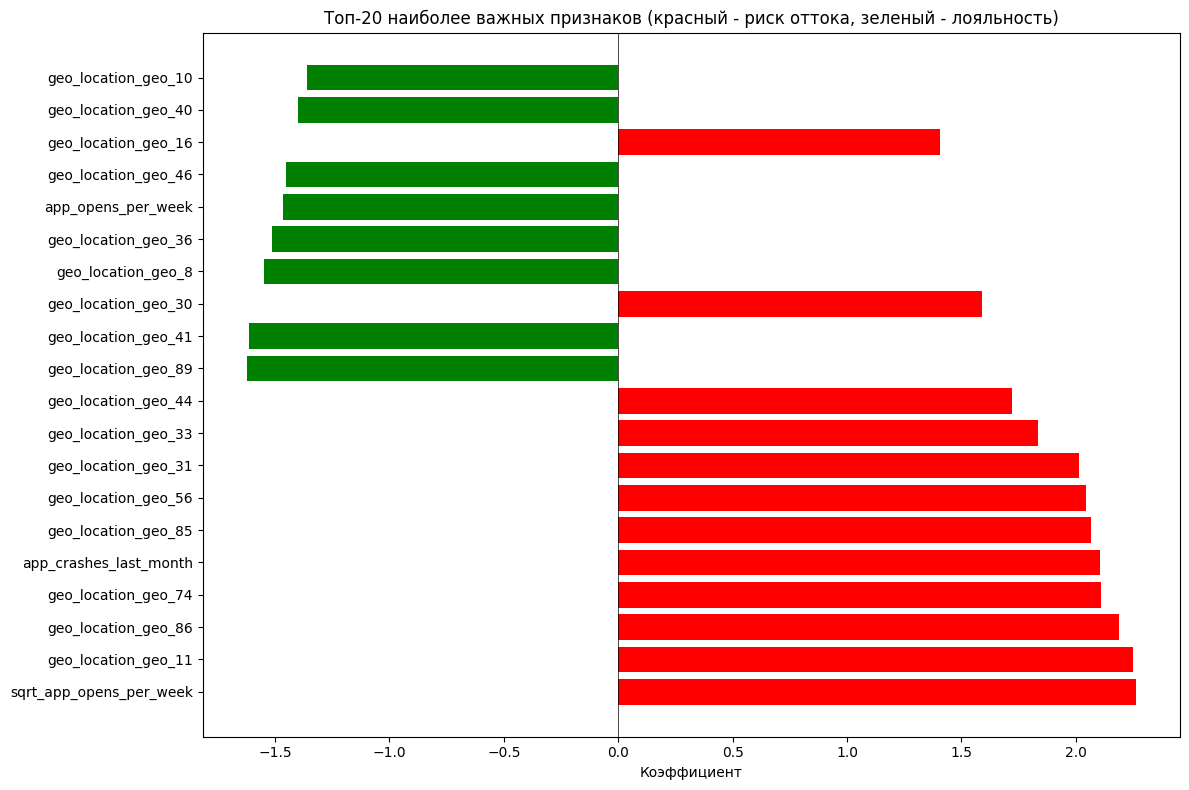

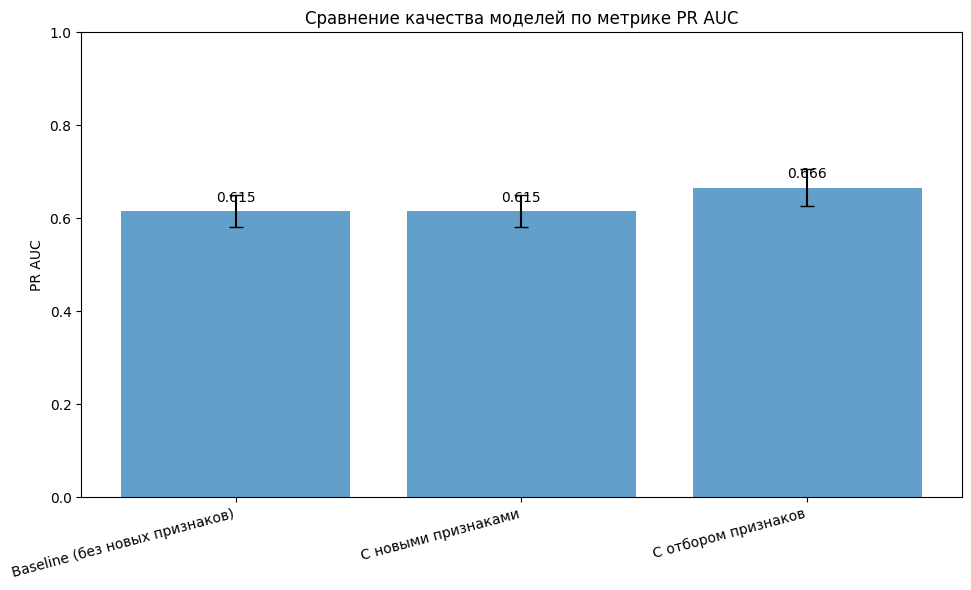

In [69]:
# Визуализация топ-20 важных признаков
plt.figure(figsize=(12, 8))
top_features = coef_df.head(20)

colors = ['red' if x > 0 else 'green' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Коэффициент')
plt.title('Топ-20 наиболее важных признаков (красный - риск оттока, зеленый - лояльность)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Визуализация улучшения PR AUC
plt.figure(figsize=(10, 6))
model_names = list(models_comparison.keys())
pr_auc_scores = [np.mean(results['test_average_precision']) for results in models_comparison.values()]
pr_auc_std = [np.std(results['test_average_precision']) for results in models_comparison.values()]

plt.bar(model_names, pr_auc_scores, yerr=pr_auc_std, capsize=5, alpha=0.7)
plt.ylabel('PR AUC')
plt.title('Сравнение качества моделей по метрике PR AUC')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
for i, (score, std) in enumerate(zip(pr_auc_scores, pr_auc_std)):
    plt.text(i, score + 0.02, f'{score:.3f}', ha='center')
plt.tight_layout()
plt.show()

In [71]:
# Итоговый отчет по этапу 5
print("\n" + "=" * 70)
print("ИТОГИ ЭТАПА 5: СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ")
print("=" * 70)

print("\n1. ДОБАВЛЕННЫЕ ПРИЗНАКИ:")
print("   - Трансформации: квадратный корень, квадрат, логарифм")
print("   - Комбинированные: avg_spend_per_order, promo_engagement, risk_score")
print("   - Бизнес-метрики: inactivity_risk, loyalty_score")

print("\n2. УЛУЧШЕНИЕ КАЧЕСТВА:")
improvement = (np.mean(cv_lr_feat_results['test_average_precision']) - 
               np.mean(cv_lr_balance_results['test_average_precision'])) * 100
print(f"   - PR AUC улучшился на {improvement:.4f}%")

print("\n3. КЛЮЧЕВЫЕ ПРИЗНАКИ, ВЛИЯЮЩИЕ НА ОТТОК:")
print("   Положительное влияние (увеличивают риск оттока):")
for feat in increasing_risk.head(5)['feature'].values:
    print(f"     • {feat}")
print("   Отрицательное влияние (снижают риск оттока):")
for feat in decreasing_risk.head(5)['feature'].values:
    print(f"     • {feat}")

print("\n4. ОПТИМИЗАЦИЯ ПРИЗНАКОВОГО ПРОСТРАНСТВА:")
print(f"   - Исходное количество признаков: {X_train_feat_processed.shape[1]}")
print(f"   - После отбора: {X_train_reduced.shape[1]}")
print(f"   - Сокращение: {(1 - X_train_reduced.shape[1]/X_train_feat_processed.shape[1])*100:.1f}%")


ИТОГИ ЭТАПА 5: СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ

1. ДОБАВЛЕННЫЕ ПРИЗНАКИ:
   - Трансформации: квадратный корень, квадрат, логарифм
   - Комбинированные: avg_spend_per_order, promo_engagement, risk_score
   - Бизнес-метрики: inactivity_risk, loyalty_score

2. УЛУЧШЕНИЕ КАЧЕСТВА:
   - PR AUC улучшился на 0.0000%

3. КЛЮЧЕВЫЕ ПРИЗНАКИ, ВЛИЯЮЩИЕ НА ОТТОК:
   Положительное влияние (увеличивают риск оттока):
     • sqrt_app_opens_per_week
     • geo_location_geo_11
     • geo_location_geo_86
     • geo_location_geo_74
     • app_crashes_last_month
   Отрицательное влияние (снижают риск оттока):
     • geo_location_geo_89
     • geo_location_geo_41
     • geo_location_geo_8
     • geo_location_geo_36
     • app_opens_per_week

4. ОПТИМИЗАЦИЯ ПРИЗНАКОВОГО ПРОСТРАНСТВА:
   - Исходное количество признаков: 141
   - После отбора: 22
   - Сокращение: 84.4%


## [Этап 6. Эксперименты с гиперпараметрами <a id=6></a>](#content)

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

## [Этап 7. Подготовка финальной модели <a id=7></a>](#content)

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


## [Этап 8. Отчёт о проделанной работе <a id=8></a>](#content)

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

## [Этап 9. Сохранение модели для продакшена <a id=9></a>](#content)

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.